## 对音频信号频域的分析

In [1]:
%matplotlib inline
import librosa
import numpy as np

from IPython import display
from matplotlib import pyplot as plt

In [2]:
# 先加载音频：指定一下采样率为16k
filepath = "../../../data/audio/test/001.wav"
data, sampling_rate = librosa.load(filepath, sr=16000, mono=True)
data.shape, sampling_rate

((131370,), 16000)

In [3]:
# 计算帧移hop_length：帧长win_length
frame_time = 25       # 25ms帧长
hop_length_time = 10  # 10ms步长

# 现在计算出win_length, hop_length
win_length = int(frame_time * sampling_rate / 1000)
hop_length = int(hop_length_time * sampling_rate / 1000)
win_length, hop_length

(400, 160)

In [4]:
n_fft = int(2**np.ceil(np.log2(win_length)))
n_fft

512

In [5]:
S = np.abs(
    librosa.stft(data, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
)
type(S), S.shape

(numpy.ndarray, (257, 822))

`S` 输出维度`[D, N]`:    
- D = `n_fft / 2 + 1`
- `N = len(y) / hop_length`

In [6]:
n_fft / 2 + 1, len(data) / hop_length

(257.0, 821.0625)

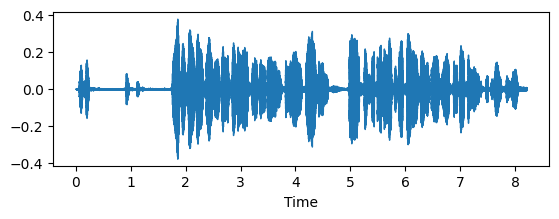

In [7]:
plt.figure().set_figheight(2)
librosa.display.waveshow(y=data, sr=sampling_rate)
plt.show()

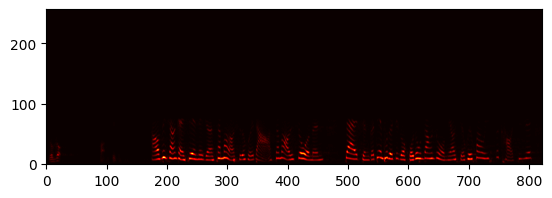

In [8]:
plt.imshow(S, origin='lower', cmap='hot')
plt.show()

In [9]:
S = librosa.amplitude_to_db(S, ref=np.max)
D, N = S.shape

range_D = np.arange(0, D, 20)
range_N = np.arange(0, N, 20)
range_t = range_N * (hop_length / sampling_rate)
range_f = range_D * (sampling_rate / n_fft / 1000)

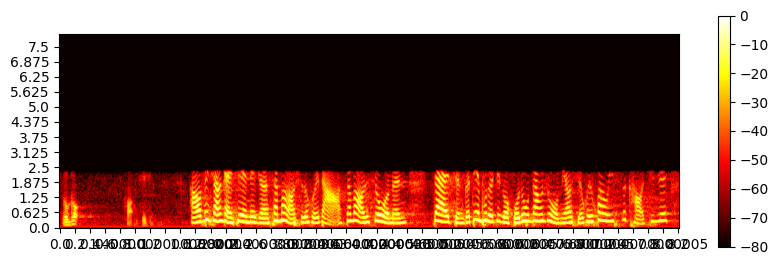

In [10]:
fig = plt.figure(figsize=(10, 3))
plt.xticks(range_N, range_t)
plt.yticks(range_D, range_f)

plt.imshow(S, origin='lower', cmap='hot')
plt.colorbar()
# plt.show()